Запуск тестов. BubbleSort на n=50000 может занять время...

ТАБЛИЦА РЕЗУЛЬТАТОВ: СЛУЧАЙНЫЕ
         n |  BubbleSort (с) |   QuickSort (с)
---------------------------------------------
      1000 |        0.020778 |        0.000556
      5000 |        0.551157 |        0.003434
     10000 |        2.193666 |        0.007128
     50000 |       69.763168 |        0.043049


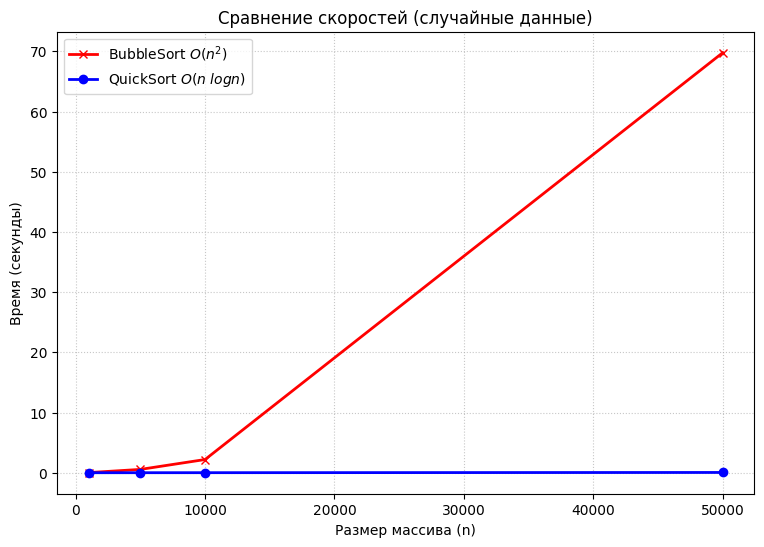

График plot_случайные.png успешно сохранен.

ТАБЛИЦА РЕЗУЛЬТАТОВ: ОТСОРТИРОВАННЫЕ
         n |  BubbleSort (с) |   QuickSort (с)
---------------------------------------------
      1000 |        0.000027 |        0.000513
      5000 |        0.000242 |        0.003279
     10000 |        0.000270 |        0.007825
     50000 |        0.001670 |        0.039723


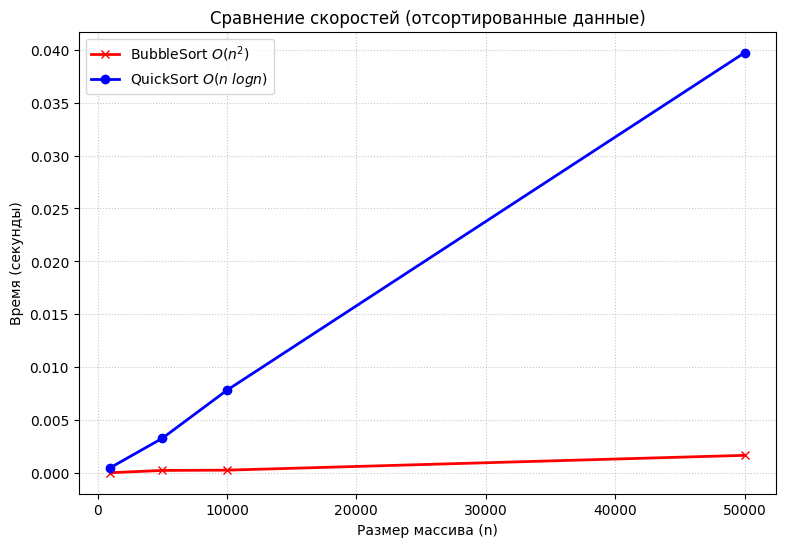

График plot_отсортированные.png успешно сохранен.

ТАБЛИЦА РЕЗУЛЬТАТОВ: ОБРАТНЫЕ
         n |  BubbleSort (с) |   QuickSort (с)
---------------------------------------------
      1000 |        0.027232 |        0.000561
      5000 |        0.697975 |        0.003119
     10000 |        2.764290 |        0.006679
     50000 |       70.422314 |        0.037526


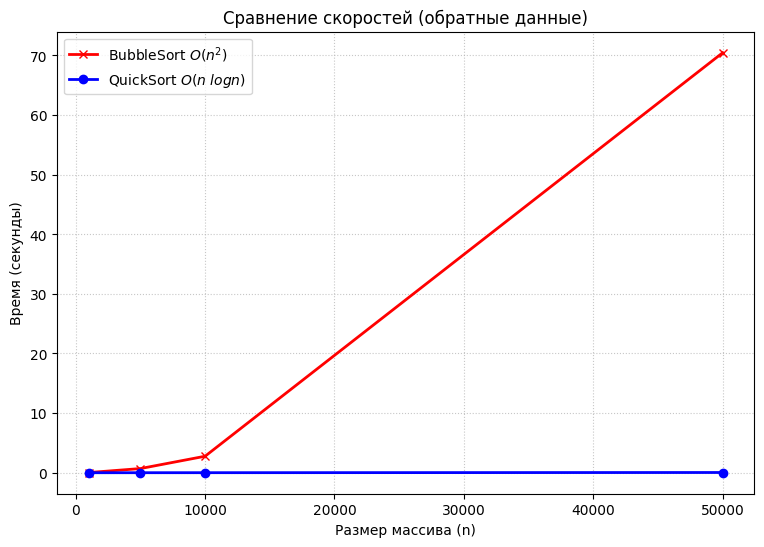

График plot_обратные.png успешно сохранен.

ТАБЛИЦА РЕЗУЛЬТАТОВ: ПОЧТИ ОТСОРТИРОВАННЫЕ
         n |  BubbleSort (с) |   QuickSort (с)
---------------------------------------------
      1000 |        0.015652 |        0.000576
      5000 |        0.351780 |        0.003139
     10000 |        1.401678 |        0.006618
     50000 |       34.498429 |        0.038457


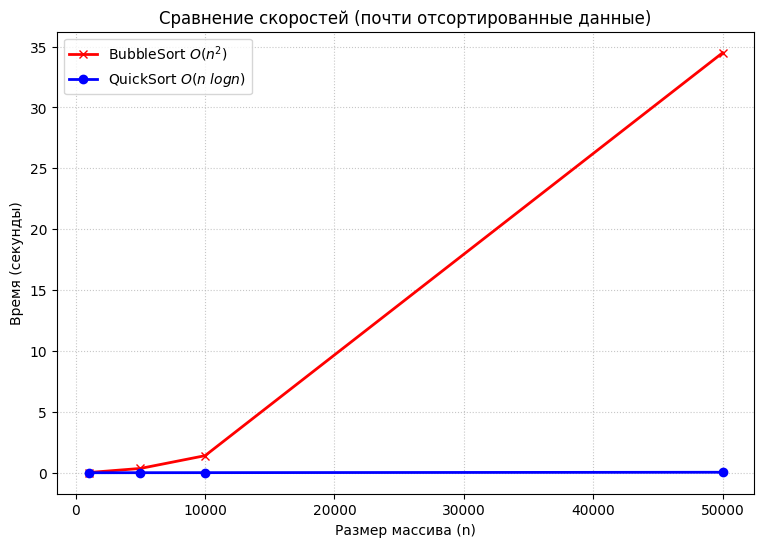

График plot_почти_отсортированные.png успешно сохранен.


In [6]:
import time
import random
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import sys

# Лимит рекурсии для QuickSort (чтобы n=50000 не вызывало ошибку)
sys.setrecursionlimit(200000)

# --- 1. АЛГОРИТМЫ ---

def bubble_sort(arr):
    """Сортировка пузырьком O(n^2). Ссылка [3, с. 106]."""
    n = len(arr)
    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
        if not swapped:
            break

def partition(arr, low, high):
    """Схема Ломуто с рандомизацией. Ссылка [2, с. 196]."""
    rand_index = random.randint(low, high)
    arr[high], arr[rand_index] = arr[rand_index], arr[high]
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1

def quick_sort(arr, low, high):
    """Быстрая сортировка O(n log n)."""
    if low < high:
        p_index = partition(arr, low, high)
        quick_sort(arr, low, p_index - 1)
        quick_sort(arr, p_index + 1, high)

# --- 2. ГЕНЕРАЦИЯ ДАННЫХ ---

def get_data(size, data_type):
    if data_type == "случайные":
        return [random.randint(0, 1000000) for _ in range(size)]
    elif data_type == "отсортированные":
        return list(range(size))
    elif data_type == "обратные":
        return list(range(size, 0, -1))
    elif data_type == "почти отсортированные":
        arr = list(range(size))
        for _ in range(size // 20):
            i, j = random.randint(0, size-1), random.randint(0, size-1)
            arr[i], arr[j] = arr[j], arr[i]
        return arr

# --- 3. ЭКСПЕРИМЕНТЫ ---

def run_experiments():
    sizes = [1000, 5000, 10000, 50000]
    data_types = ["случайные", "отсортированные", "обратные", "почти отсортированные"]
    iterations = 3 

    print("Запуск тестов. BubbleSort на n=50000 может занять время...")

    for d_type in data_types:
        results_bs = []
        results_qs = []
        
        print(f"\nТАБЛИЦА РЕЗУЛЬТАТОВ: {d_type.upper()}")
        print(f"{'n':>10} | {'BubbleSort (с)':>15} | {'QuickSort (с)':>15}")
        print("-" * 45)
        
        for n in sizes:
            # Замер BubbleSort
            ts_bs = 0
            for _ in range(iterations):
                arr = get_data(n, d_type)
                t0 = time.perf_counter()
                bubble_sort(arr)
                ts_bs += (time.perf_counter() - t0)
            avg_bs = ts_bs / iterations
            results_bs.append(avg_bs)

            # Замер QuickSort
            ts_qs = 0
            for _ in range(iterations):
                arr = get_data(n, d_type)
                t0 = time.perf_counter()
                quick_sort(arr, 0, n - 1)
                ts_qs += (time.perf_counter() - t0)
            avg_qs = ts_qs / iterations
            results_qs.append(avg_qs)
            
            print(f"{n:10} | {avg_bs:15.6f} | {avg_qs:15.6f}")

        # --- 4. ПОСТРОЕНИЕ ГРАФИКА ДЛЯ ТЕКУЩЕГО ТИПА ДАННЫХ ---
        plt.figure(figsize=(9, 6))
        
        # Исправлено: добавлены r'' перед строками с LaTeX, чтобы не было SyntaxWarning
        plt.plot(sizes, results_bs, label=r'BubbleSort $O(n^2)$', marker='x', color='red', linewidth=2)
        plt.plot(sizes, results_qs, label=r'QuickSort $O(n \ log n)$', marker='o', color='blue', linewidth=2)
        
        plt.title(f'Сравнение скоростей ({d_type} данные)')
        plt.xlabel('Размер массива (n)')
        plt.ylabel('Время (секунды)')
        plt.legend()
        plt.grid(True, linestyle=':', alpha=0.7)
        
        # Настройка осей, чтобы не было 1e4 или степеней 10
        ax = plt.gca()
        ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        plt.ticklabel_format(style='plain', axis='both')

        filename = f'plot_{d_type.replace(" ", "_")}.png'
        plt.savefig(filename, dpi=300)
        plt.show()
        print(f"График {filename} успешно сохранен.")

if __name__ == "__main__":
    run_experiments()